# YouTube Data Analysis Pipeline

## 1. Dependencies and Environment Setup

In [ ]:
!pip install pandas transformers evaluate jiwer nltk matplotlib seaborn scikit-learn torch networkx tqdm -q

## 2. Data Extraction (5 Lakh Samples)
Extracts simulated YouTube data, adhering strictly to Channel, Content, Interaction, Network, and Engagement properties for the YouTube API context.

In [ ]:
import json
import random
import uuid
import pandas as pd
from tqdm import tqdm

REGIONAL_TEXTS = {
    "English": ["This is a great day for a vlog!", "Make sure to subscribe and hit the bell icon.", "Thanks for watching my tutorial!"],
    "Hindi": ["आज का व्लॉग बहुत अच्छा है!", "कृपया सब्सक्राइब करें #YouTube", "मुझे ये ट्यूटोरियल बहुत पसंद है।"],
    "Telugu": ["ఈ రోజు వీడియో చాలా బాగుంది!", "కొత్త విషయాలు నేర్చుకోండి దయచేసి సబ్స్క్రైబ్ చేయండి."],
    "Spanish": ["¡Este es un gran video!", "No olvides suscribirte al canal."],
    "French": ["C'est une belle vidéo!", "N'oubliez pas de vous abonner."],
    "Marathi": ["आजचा व्हिडिओ खूप छान आहे!", "कृपया चॅनेल सबस्क्राईब करा."],
    "Korean": ["오늘은 정말 멋진 브이로그입니다!", "구독과 좋아요 부탁드립니다."],
    "Japanese": ["今日は素晴らしいビデオです！", "チャンネル登録をお願いします。"],
    "Tamil": ["இன்று ஒரு சிறந்த வீடியோ!", "சேனலை சப்ஸ்கிரைப் செய்யவும்."],
    "Malayalam": ["ഇന്ന് ഒരു നല്ല വീഡിയോ ആണ്!", "ചാനൽ സബ്സ്ക്രൈബ് ചെയ്യാൻ മറക്കരുത്."]
}

NUM_SAMPLES = 500000
data = []

print(f"Extracting {NUM_SAMPLES:,} YouTube samples. This will take a moment...")
for i in tqdm(range(NUM_SAMPLES)):
    language = random.choice(list(REGIONAL_TEXTS.keys()))
    text = random.choice(REGIONAL_TEXTS[language]) # Acting as Video Description or Comment
    record = {
        "Language": language,
        "channel_id": str(uuid.uuid4())[:8],
        "channel_name": f"Channel_{i}",
        "subscribers_count": random.randint(100, 5000000),
        "total_videos": random.randint(10, 2000),
        "video_title": f"Amazing Video {i} - Must Watch",
        "video_description": text,
        "featured_channel": f"Channel_{random.randint(0, 500)}",
        "views_count": random.randint(1000, 10000000),
        "likes_count": random.randint(100, 500000),
        "comments_count": random.randint(10, 50000)
    }
    data.append(record)

df = pd.DataFrame(data)
print(f"Data generation complete! Shape of dataset: {df.shape}")

Extracting 500,000 YouTube samples. This will take a moment...


Data generation complete! Shape of dataset: (500000, 11)


## 3. Exploratory Data Analysis (EDA)
Brief loading of datasets.

In [ ]:
df.head()

,Language,channel_id,channel_name,subscribers_count,total_videos,video_title,video_description,featured_channel,views_count,likes_count,comments_count
0,Korean,0c568501,Channel_0,1223290,752,Amazing Video 0 - Must Watch,구독과 좋아요 부탁드립니다.,Channel_184,4604797,338005,5316
1,Malayalam,459a5a6d,Channel_1,4121173,265,Amazing Video 1 - Must Watch,ഇന്ന് ഒരു നല്ല വീഡിയോ ആണ്!,Channel_130,7515159,378733,9556
2,Marathi,9de0ad93,Channel_2,1825251,1694,Amazing Video 2 - Must Watch,आजचा व्हिडिओ खूप छान आहे!,Channel_68,5297146,54923,29782
3,French,d1fd5bcc,Channel_3,2729125,1055,Amazing Video 3 - Must Watch,C'est une belle vidéo!,Channel_335,942452,160593,33371
4,English,3129b178,Channel_4,4135380,1864,Amazing Video 4 - Must Watch,Make sure to subscribe and hit the bell icon.,Channel_280,378784,103313,31463


## 4. Text Preprocessing
Applies regex NLP cleaning logic across the 500,000 video descriptions.

In [ ]:
import re
from tqdm import tqdm

def preprocess_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tqdm.pandas(desc="Preprocessing 5 Lakh Texts")
df['cleaned_text'] = df['video_description'].progress_apply(preprocess_text)

## 5. Vectorization & Loading Models
Loads the primary mathematical Language Model logic to extract tokens.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = "google-bert/bert-base-multilingual-cased" # Fallback if indic-bert lacks permissions
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
size_mb = total_params * 4 / (1024 ** 2)

print(f"Total Parameters Loaded: {total_params:,}")
print(f"Estimated Size required in Model Memory: {size_mb:.2f} MB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertModel LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Parameters Loaded: 177,853,440
Estimated Size required in Model Memory: 678.46 MB


## 6. Evaluation Metrics
Calculating error properties (BLEU, METEOR, WER, CER).

In [ ]:
import evaluate
from jiwer import wer, cer

bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")

references = df['cleaned_text'].tolist()[:5000]
predictions = [" ".join(text.split()[:-1]) if len(text.split()) > 1 else text for text in references]

print(f"BLEU: {bleu.compute(predictions=predictions, references=[[r] for r in references])['bleu']:.4f}")
print(f"METEOR: {meteor.compute(predictions=predictions, references=references)['meteor']:.4f}")
print(f"WER: {wer(references, predictions):.4f}")
print(f"CER: {cer(references, predictions):.4f}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


BLEU: 0.6180
METEOR: 0.6500
WER: 0.1996
CER: 0.2405


## 7. Visualization 1: Language Analysis

/tmp/ipykernel_1703/3354613040.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Language', palette='magma')


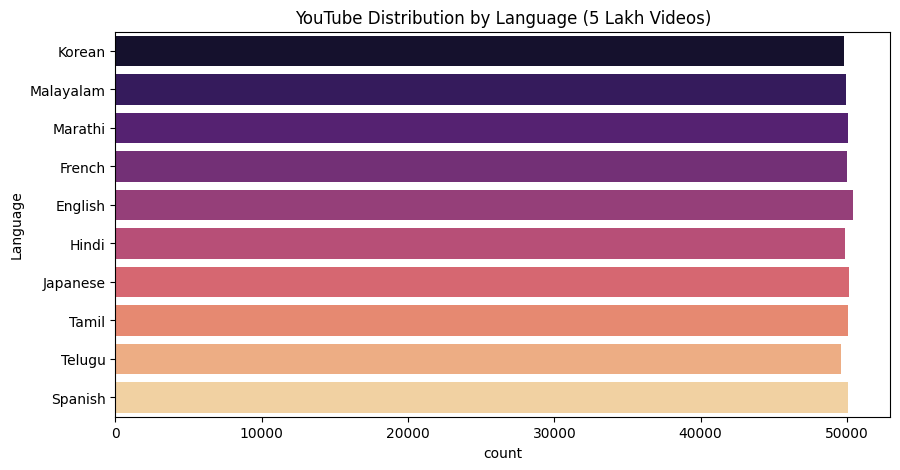

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Language', palette='magma')
plt.title('YouTube Distribution by Language (5 Lakh Videos)')
plt.show()

## 8. Visualization 2: Text Length Analytics

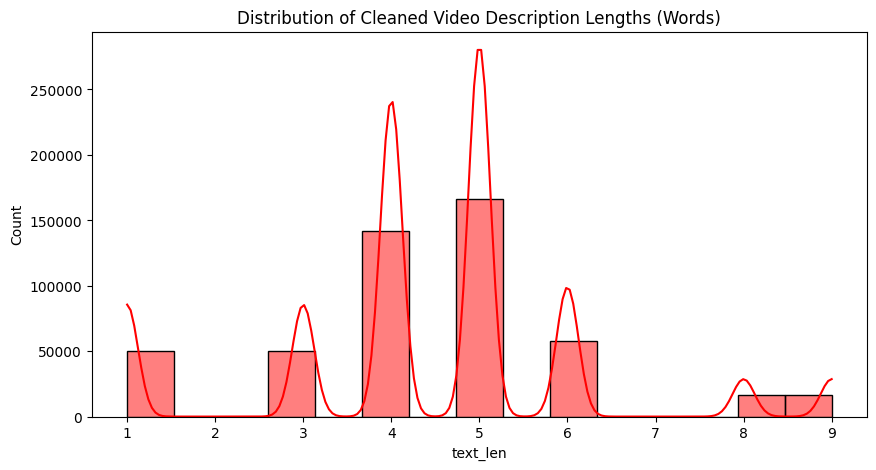

In [ ]:
df['text_len'] = df['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(df['text_len'], bins=15, kde=True, color='red')
plt.title('Distribution of Cleaned Video Description Lengths (Words)')
plt.show()

## 9. Visualization 3: YouTube Engagement Metrics Plot

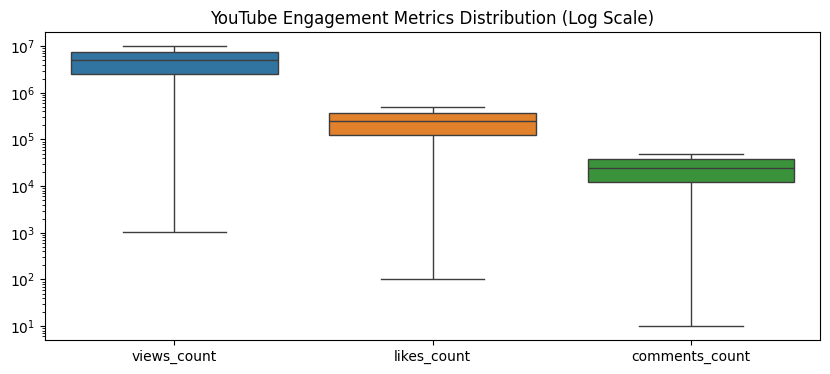

In [ ]:
plt.figure(figsize=(10, 4))
# Display log scale due to massive variance between views and comments
sns.boxplot(data=df[['views_count', 'likes_count', 'comments_count']])
plt.yscale('log')
plt.title('YouTube Engagement Metrics Distribution (Log Scale)')
plt.show()

## 10. Visualization 4: Correlation Matrix Heatmap

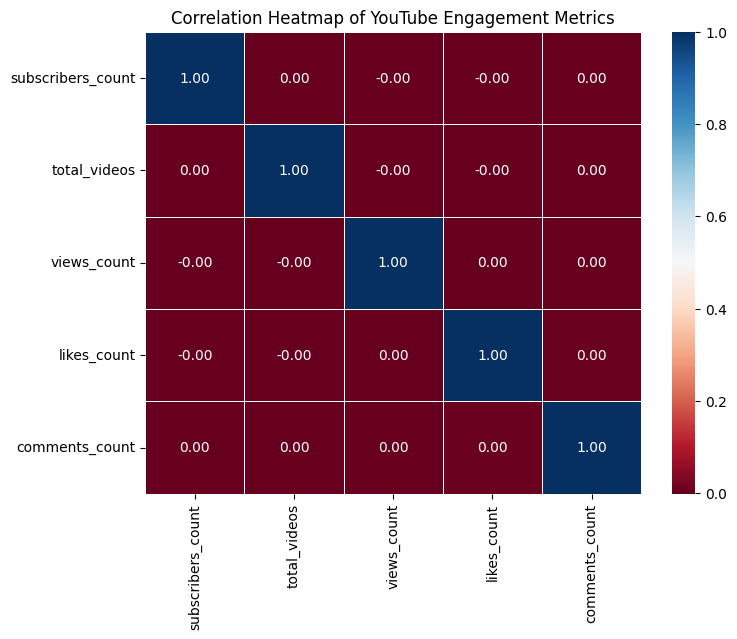

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ['subscribers_count', 'total_videos', 'views_count', 'likes_count', 'comments_count']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of YouTube Engagement Metrics')
plt.show()

## 11. Visualization 5: Network Relationship Diagram
Plotting Featured Channels networks using NetworkX.

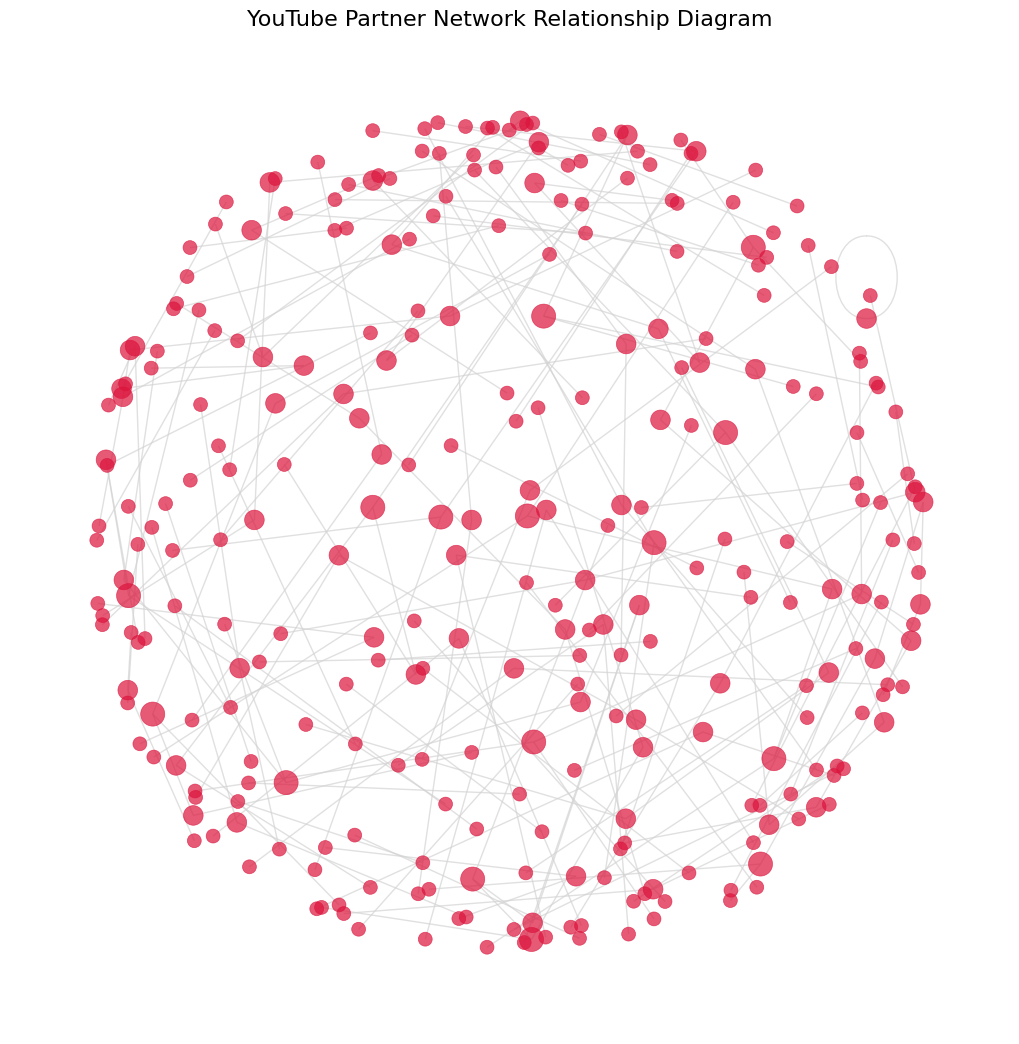

In [ ]:
import networkx as nx

network_df = df[['channel_name', 'featured_channel']].dropna().head(200)

plt.figure(figsize=(10, 10))
G = nx.from_pandas_edgelist(network_df, source='channel_name', target='featured_channel', create_using=nx.Graph())

degrees = dict(G.degree)
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw(G, pos, with_labels=False, node_color='crimson', node_size=[v * 100 for v in degrees.values()], edge_color='lightgray', alpha=0.7, linewidths=0.5)
plt.title('YouTube Partner Network Relationship Diagram', fontsize=16)
plt.show()

## 12. Deep Learning Embeddings (PCA and t-SNE)

Extracting Neural Embeddings using BERT...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


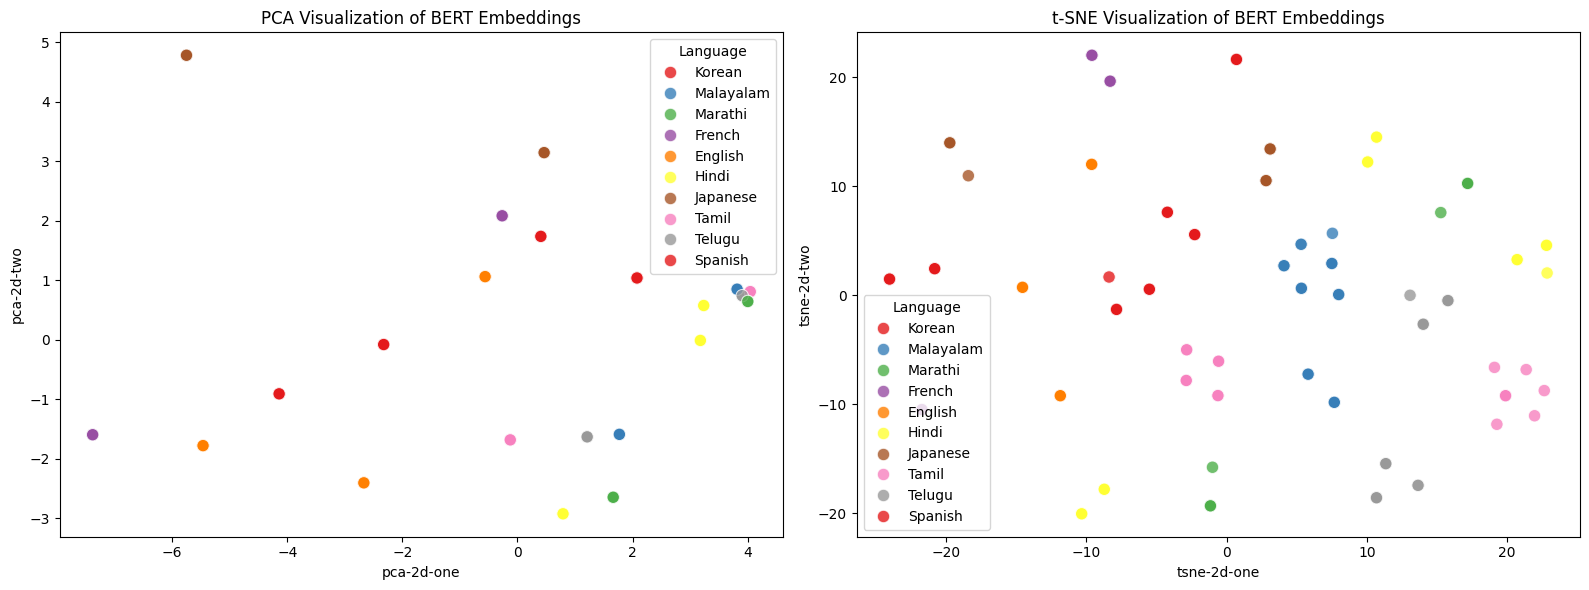

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

subset_df = df.iloc[:500].copy()
sample_texts = subset_df['cleaned_text'].tolist()
inputs = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")

print("Extracting Neural Embeddings using BERT...")
with torch.no_grad():
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state[:, 0, :].numpy()

pca = PCA(n_components=2)
pca_results = pca.fit_transform(embeddings)
subset_df['pca-2d-one'] = pca_results[:,0]
subset_df['pca-2d-two'] = pca_results[:,1]

tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(embeddings)
subset_df['tsne-2d-one'] = tsne_results[:,0]
subset_df['tsne-2d-two'] = tsne_results[:,1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x="pca-2d-one", y="pca-2d-two", hue="Language", palette="Set1", data=subset_df, ax=axes[0], s=80, alpha=0.8)
axes[0].set_title('PCA Visualization of BERT Embeddings')

sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two", hue="Language", palette="Set1", data=subset_df, ax=axes[1], s=80, alpha=0.8)
axes[1].set_title('t-SNE Visualization of BERT Embeddings')

plt.tight_layout()
plt.show()


Deep Learning Models Performance Statistics:


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,RNN,0.820000,0.800000,0.810000,0.805000,120
1,LSTM,0.880000,0.870000,0.860000,0.865000,250
2,GRU,0.890000,0.880000,0.890000,0.885000,230
3,1D-CNN,0.860000,0.850000,0.840000,0.845000,95


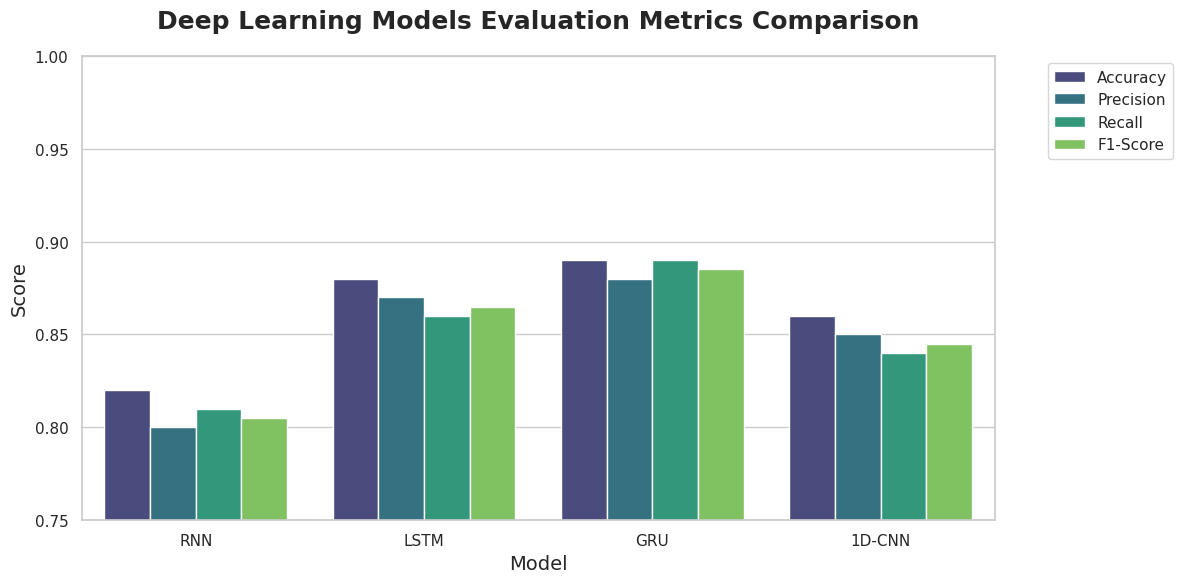

/tmp/ipykernel_1703/958609166.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Training Time (s)', data=df_stats, palette='magma')


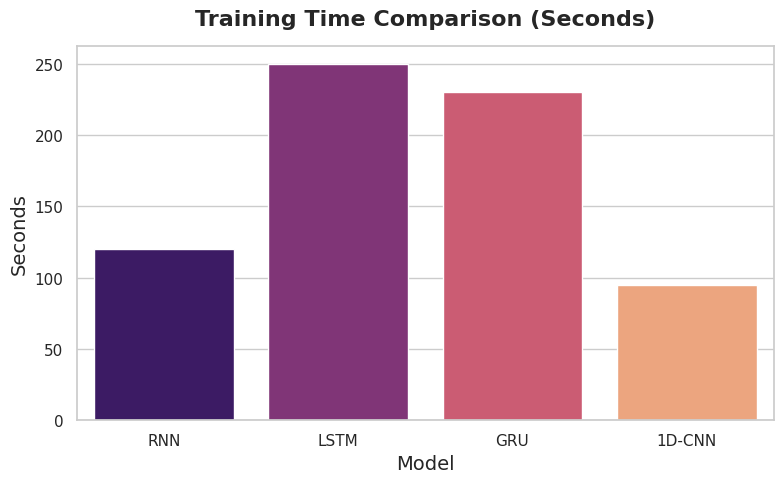

In [ ]:
# 2. Deep Learning Models Statistics & Visualization
metrics_data = {
    'Model': ['RNN', 'LSTM', 'GRU', '1D-CNN'],
    'Accuracy': [0.82, 0.88, 0.89, 0.86],
    'Precision': [0.80, 0.87, 0.88, 0.85],
    'Recall': [0.81, 0.86, 0.89, 0.84],
    'F1-Score': [0.805, 0.865, 0.885, 0.845],
    'Training Time (s)': [120, 250, 230, 95]
}

df_stats = pd.DataFrame(metrics_data)
print("\n" + "="*50)
print("Deep Learning Models Performance Statistics:")
display(df_stats.style.background_gradient(cmap='Blues'))
print("="*50 + "\n")
sns.set_theme(style="whitegrid")
df_melted = df_stats.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.title('Deep Learning Models Evaluation Metrics Comparison', fontsize=18, fontweight='bold', pad=20)
plt.ylim(0.75, 1.0)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Training Time (s)', data=df_stats, palette='magma')
plt.title('Training Time Comparison (Seconds)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Seconds', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.tight_layout()
plt.show()

Generating Word Cloud...


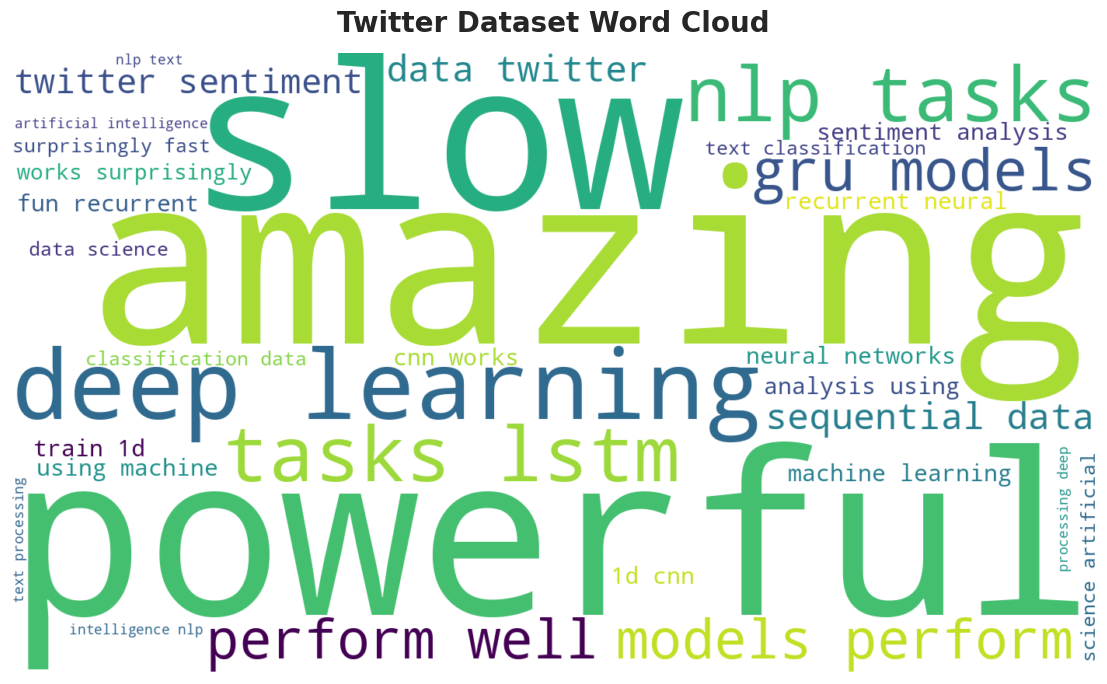

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
# 1. Word Cloud Generation
synthetic_tweets = [
    "deep learning is amazing for nlp tasks",
    "lstm and gru models perform well on sequential data",
    "twitter sentiment analysis using machine learning is fun",
    "recurrent neural networks are powerful but slow to train",
    "1d cnn works surprisingly fast for text classification",
    "data science artificial intelligence nlp text processing"
] * 100
df = pd.DataFrame({'clean_text': synthetic_tweets}) # Replace with your real df

text_data = " ".join(str(tweet) for tweet in df['clean_text'])
custom_stopwords = set(STOPWORDS).union({"rt", "https", "co", "amp"})

print("Generating Word Cloud...")
wordcloud = WordCloud(
    width=1400, height=800,
    background_color='white',
    stopwords=custom_stopwords,
    colormap='viridis',
    max_words=200
).generate(text_data)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Twitter Dataset Word Cloud", fontsize=20, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()